#### 4월 10일
RNN 설명

시계열은 시작할 때, 이전의 정보가 없음.
- 이전 값을 받아서 갱신해야 하는데 이전 W, b 가 없기 때문에
- 최초에 초기값을 입력해서 들어가야 함.

foward 할떄는 출력값.
cnn 할때는 결과가 FeatureMap
rnn 할때는 결과가 은닉층Hidden state라는 이름으로 나옴.
이름만 다른것

RNN특 -> 결과를 자기자신에게 돌려줌

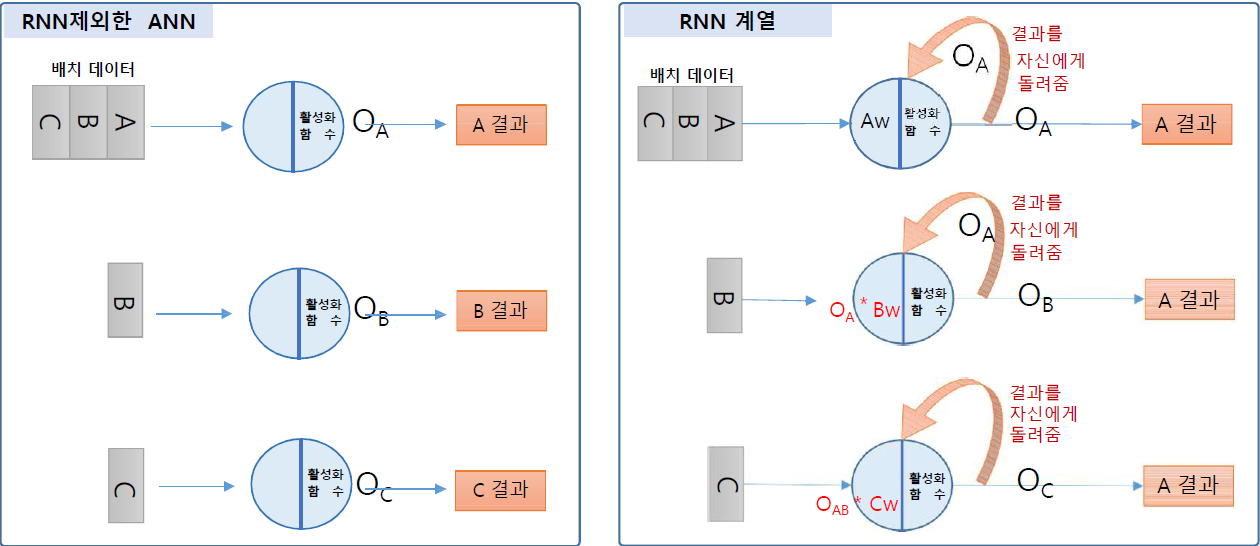

활성화함수로 하이퍼볼릭 탄젠트 사용 tanh
- Sigmoid 함수와 같은 형태
- 출력값: -1 ~ 1
- 최대값이 1이기 떄문에 Vanishing Gradien 현상 완화. 해결은 아님

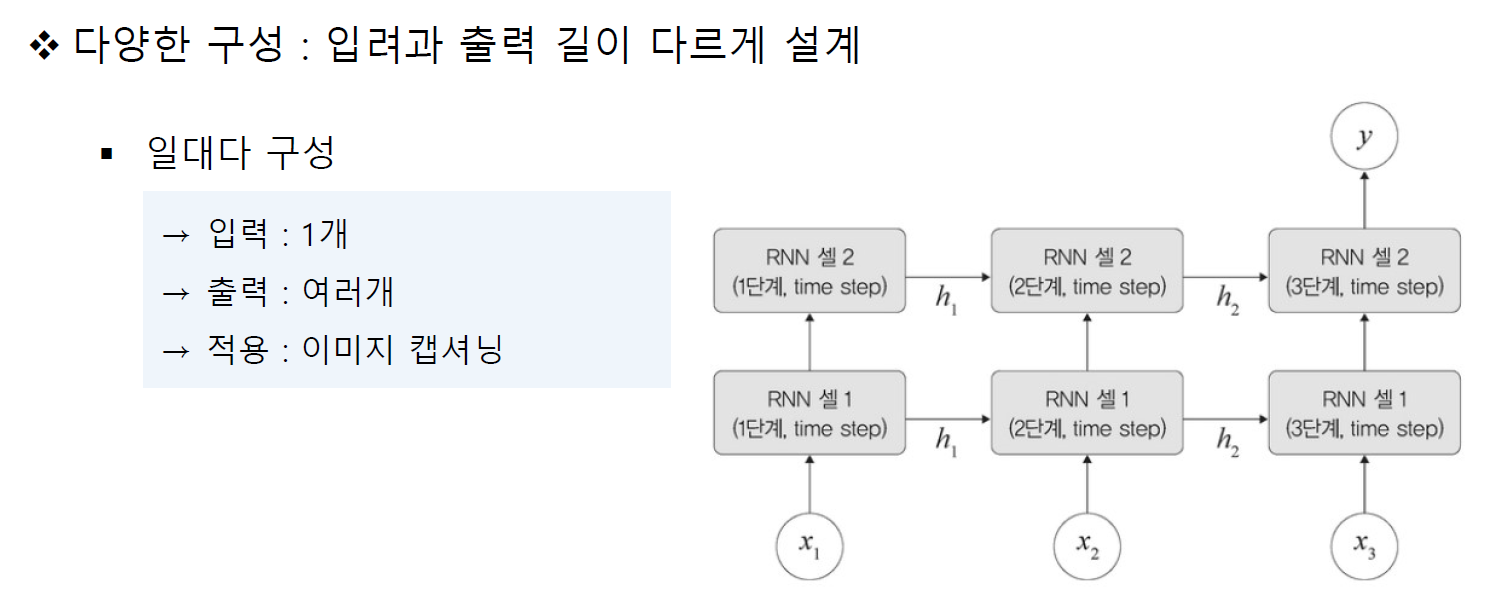

각 셀은 정보를 기억하고 있고, 거듭할수록 누적된 정보를 소화해서 최종단으로 넘겨준다.

- 각각의 단어에 대한 h값,
- 최종적으로 누적된 정보의 h 값.
2가지를 출력

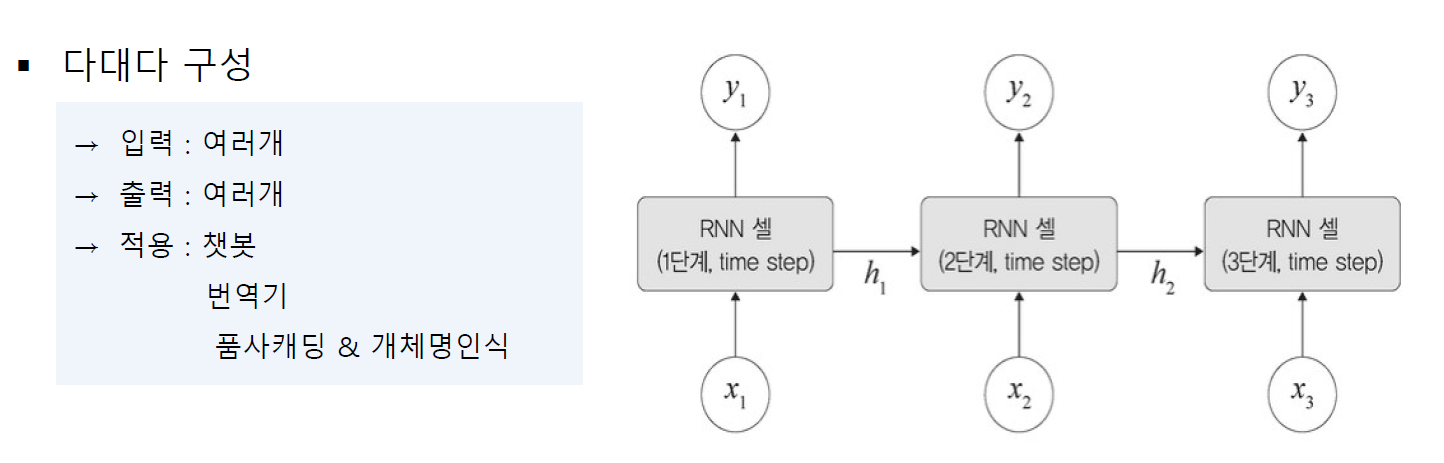

* 한계 ==> 먼 과거에 나온 정보에서 새로운 정보 유추 불가능
==> 장기 의존성 문제 (Long Term Dependency)

* 해결방안
* LSTM
    - 장기의존성 문제 해결
    - 역전파 시 기울기 소실 문제 해결

#### autograd
- 가중합으로 얻어낸 grad정보를 역전파하여 퍼셉트론에 전달하는데,
- 이걸 누적하지 않기 위해서 기존에 있던 기울기정보를 
- zero_grad로 초기화하고, 역전파로 전달받은 기울기정보를 사용
- 다시 가중합연산 실행하여 결과를 낸다

#### LSTM : Long Short Term Memory  p.313
- RNN 장기의존성 문제, 기울기 소실 문제 해결한 알고리즘 중 하나
- RNN보다 복잡한 구조
- 과거의 기억을 보존하되, 필요가 없어진 기억을 지워버리는 기능 추가
- RNN의 기울기 소실/폭주 문제 해결 요소 즉, Cell State 추가

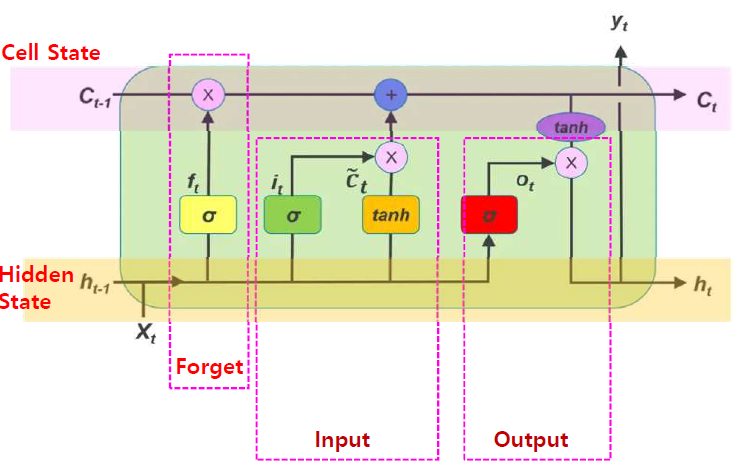

* cell state
    - 정보를 저장하고 유지하는 메모리 역할. 출력게이트와 망각게이트가 제어

* forget gate 망각 게이트
    - 장단기 메모리에서 이전 셀 상태에서 어더한 정보를 삭제할지 결정하는 역할.
    - 현재 입력과 이전 셀 상태를 입력으로 받아 어떤 정보를 삭제할지 결정

* input gate 입력 게이트
    - 새로운 정보를 어떤 부분에 추가할지 결정하는 역할
    - 현재 입력과 이전 셀상태를 받아 어떤 정보를 추가할지 결정

* output gate 출력 게이트
    - 셀 상태의 정보중 어떤 부분을 출력할지 결정.
    

#### GRU : Gated Recurrent Unit
- LSTM 장기 의존성 문제 해결책 유지하며, 은닉 상태 업데이트 계산 줄여줌
- GRU는 성능은 LSTM과 유사하면서 복잡했던 LSTM 구조 간단화
- LSTM의 Cell State를 없애고 Hidden State만 활용한 모델
- Reset Gate와 Update Gate만 존재

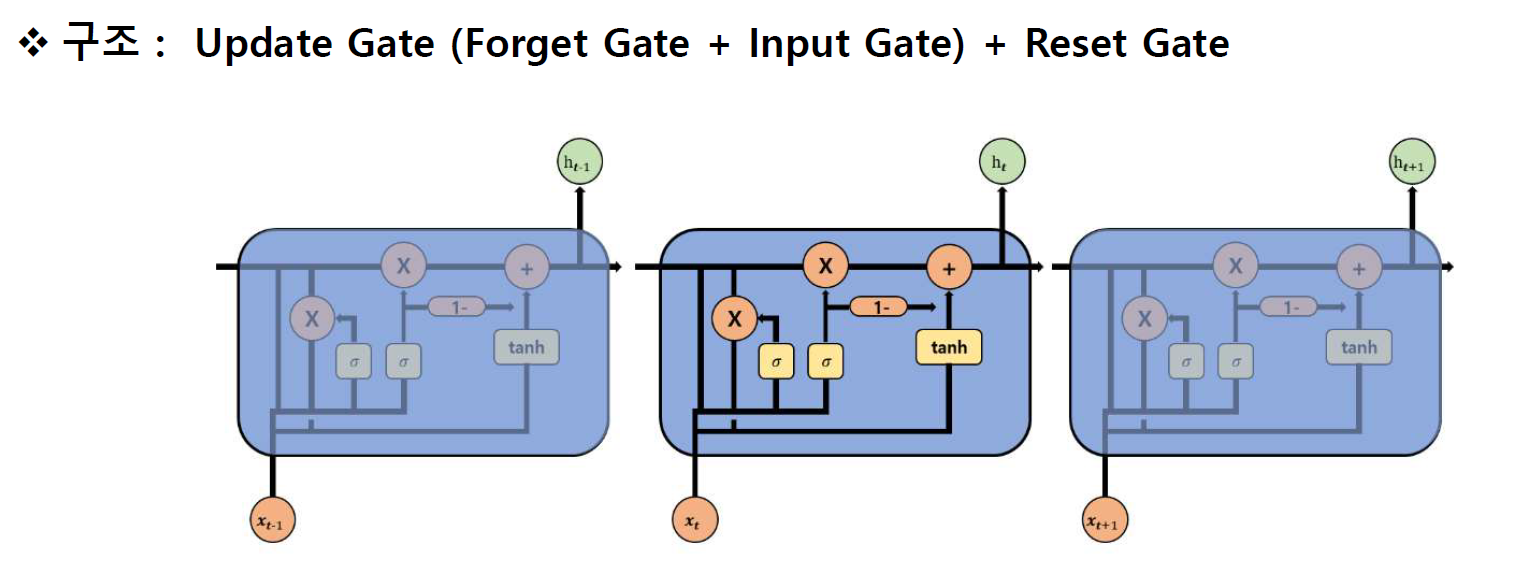

#### Word Embedding
- 단어를 벡터로 표현하는 것으로 밀집 표현(dense representation)
- 벡터의 차원 => 사용자가 설정한 값으로 모든 단어의 벡터 표현의 차원 설정

- 0과 1만 가진 값이 아니라 실수값 가짐
- 밀집 벡터를 워드 임베딩 과정을 통해 나온 결과 => Embedding 
Vector


- 적용모델 : LSA, Word2Vec, FastText, Glove
* 파이토치
    - ① 훈련 데이터로부터 처음부터 임베딩 벡터를 학습하는 방법
    - ② 미리 사전에 훈련된 임베딩 벡터(pre-trained word embedding) 활용하는 방법

* Embedding Layer
    - 조건 : 입력 시퀀스의 각 단어들은 모두 정수 인코딩 되어 있어야 함
    - 결과 : 입력 정수에 대해 밀집 벡터(dense vector)로 맵핑
    - 학습 : 인공 신경망의 학습 과정에서 가중치가 학습되는 것과 같은 방식으로 훈련

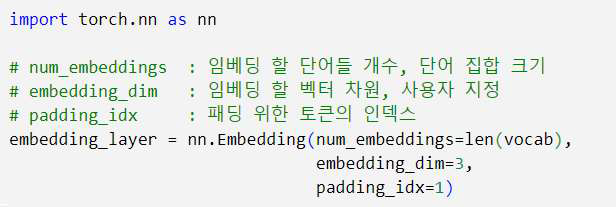

* 스킵그램(Skip-gram)
    - 자연어 처리(NLP)에서 단어를 벡터로 표현하기 위해 사용하는 Word2Vec 모델 중 하나
    - 중심 단어로부터 주변 단어를 예측하는 모델

* “I love natural language processing”

- 여기서 window size = 2라면, 중심 단어 love의 
- 주변 단어는 ["I", "natural"]이 됩니다.

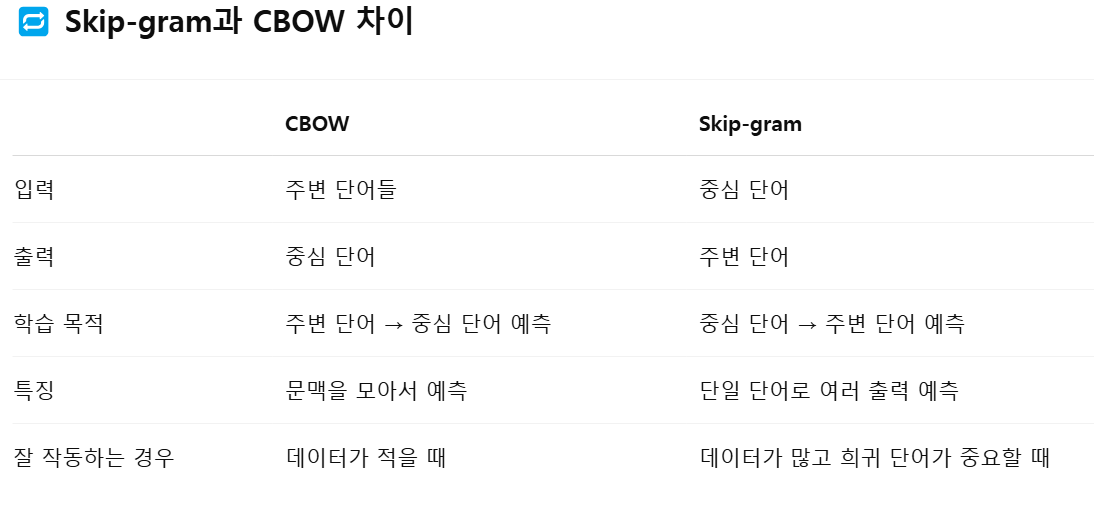

* 네거티브 샘플링
    - Skip-gram 모델에서 전체 단어 수(vocab size)가 너무 클 때, 모든 단어에 대해 softmax 확률을 계산하지 않고, 일부 “가짜(negative)” 단어만 뽑아서 학습하는 기법

* 목표: 중심 단어 → 주변 단어

    - 단어 수가 수만 개라면, softmax 계산량이 매번 엄청 큼 😵
    → 그래서 진짜 주변 단어 몇 개 + 랜덤 단어 몇 개만 골라서 훈련

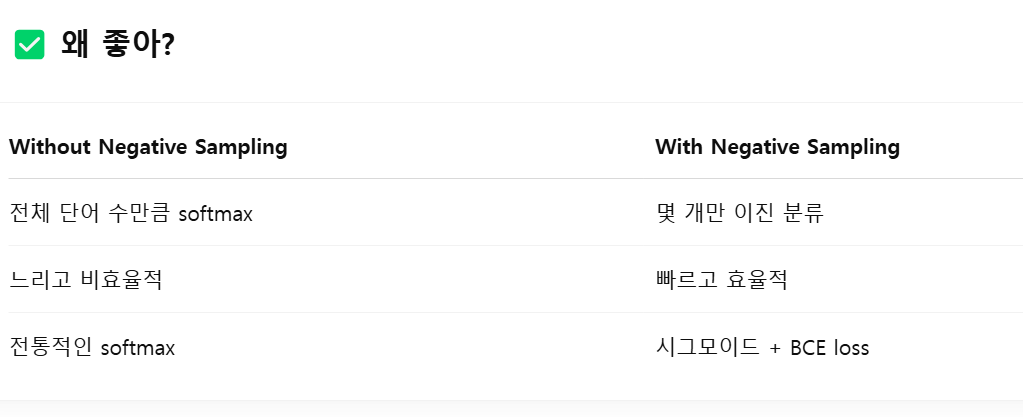

```
abc

```